Step 0, Loss: 40.7808
Step 100, Loss: 40.4165
Step 200, Loss: 40.4085
Step 300, Loss: 40.4179
Step 400, Loss: 40.4145
Step 500, Loss: 40.4196
Step 600, Loss: 40.4215
Step 700, Loss: 40.4193
Step 800, Loss: 40.4142
Step 900, Loss: 40.4139


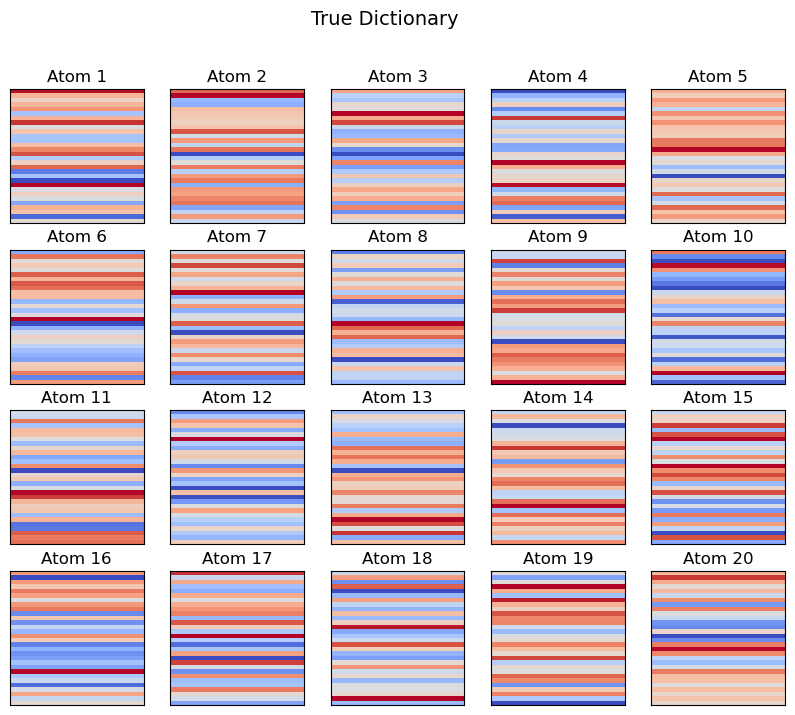

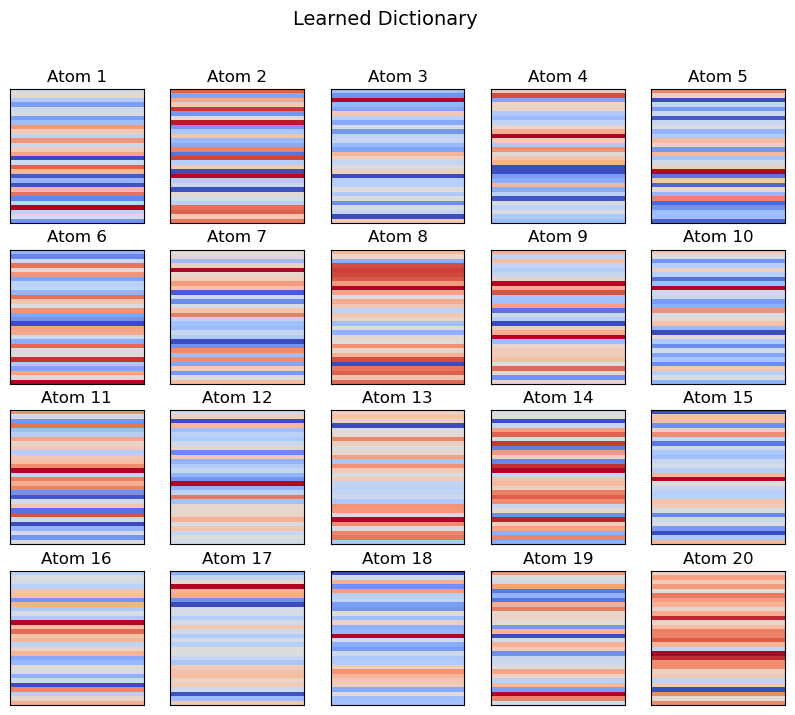

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Define the model
class OnlineDictionaryLearning(nn.Module):
    def __init__(self, num_atoms=20, data_dim=30, learning_rate=1e-3):
        super(OnlineDictionaryLearning, self).__init__()
        self.num_atoms = num_atoms  # Number of dictionary elements
        self.data_dim = data_dim    # Dimension of input data
        self.learning_rate = learning_rate

        # Initialize dictionary atoms randomly
        self.dictionary = nn.Parameter(torch.randn(self.data_dim, self.num_atoms) * 0.1)
        self.optimizer = optim.Adam([self.dictionary], lr=self.learning_rate)

    def forward(self, x):
        """Forward pass that performs sparse coding"""
        num_samples = x.shape[0]

        # Spike-and-Slab Prior (Binary Mask + Gaussian Latent Codes)
        z = torch.bernoulli(torch.full((num_samples, self.num_atoms), 0.2))  # Fixed sparsity prior
        s = torch.randn(num_samples, self.num_atoms)  # Gaussian slab
        sparse_codes = z * s  # Apply mask

        # Generate reconstructed data
        reconstruction = torch.matmul(sparse_codes, self.dictionary.T)  # (num_samples, data_dim)
        return reconstruction, sparse_codes

    def train_model(self, data, num_steps=1000):
        """Train the model using gradient descent"""
        loss_fn = nn.MSELoss()
        losses = []

        for step in range(num_steps):
            self.optimizer.zero_grad()
            reconstruction, _ = self.forward(data)

            # Compute reconstruction loss
            loss = loss_fn(reconstruction, data)
            loss.backward()
            self.optimizer.step()
            losses.append(loss.item())

            if step % 100 == 0:
                print(f"Step {step}, Loss: {loss.item():.4f}")

        return losses

# Create synthetic data with more samples and atoms
num_samples = 10000  # Increased number of samples
data_dim = 30  # Increased data dimension
num_atoms = 200  # Increased dictionary atoms

# Generate a random sparse dataset
true_dictionary = torch.randn(data_dim, num_atoms)
sparse_codes = (torch.rand(num_samples, num_atoms) > 0.8).float() * torch.randn(num_samples, num_atoms)
data = torch.matmul(sparse_codes, true_dictionary.T) + 0.1 * torch.randn(num_samples, data_dim)

# Train the model
model = OnlineDictionaryLearning(num_atoms=num_atoms, data_dim=data_dim, learning_rate=1e-2)
losses = model.train_model(data, num_steps=1000)

# Retrieve the learned dictionary
learned_dictionary = model.dictionary.detach().numpy()

# Retrieve the true dictionary used in data generation
true_dictionary_np = true_dictionary.numpy()

# Function to visualize dictionaries
def plot_dictionary(dictionary, title):
    fig, axes = plt.subplots(4, 5, figsize=(10, 8))  # Adjusted grid for more atoms
    fig.suptitle(title, fontsize=14)

    for i, ax in enumerate(axes.flat):
        if i < dictionary.shape[1]:
            ax.imshow(dictionary[:, i].reshape(-1, 1), cmap="coolwarm", aspect="auto")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Atom {i+1}")

    plt.show()

# Plot the true and learned dictionaries
plot_dictionary(true_dictionary_np, "True Dictionary")
plot_dictionary(learned_dictionary, "Learned Dictionary")

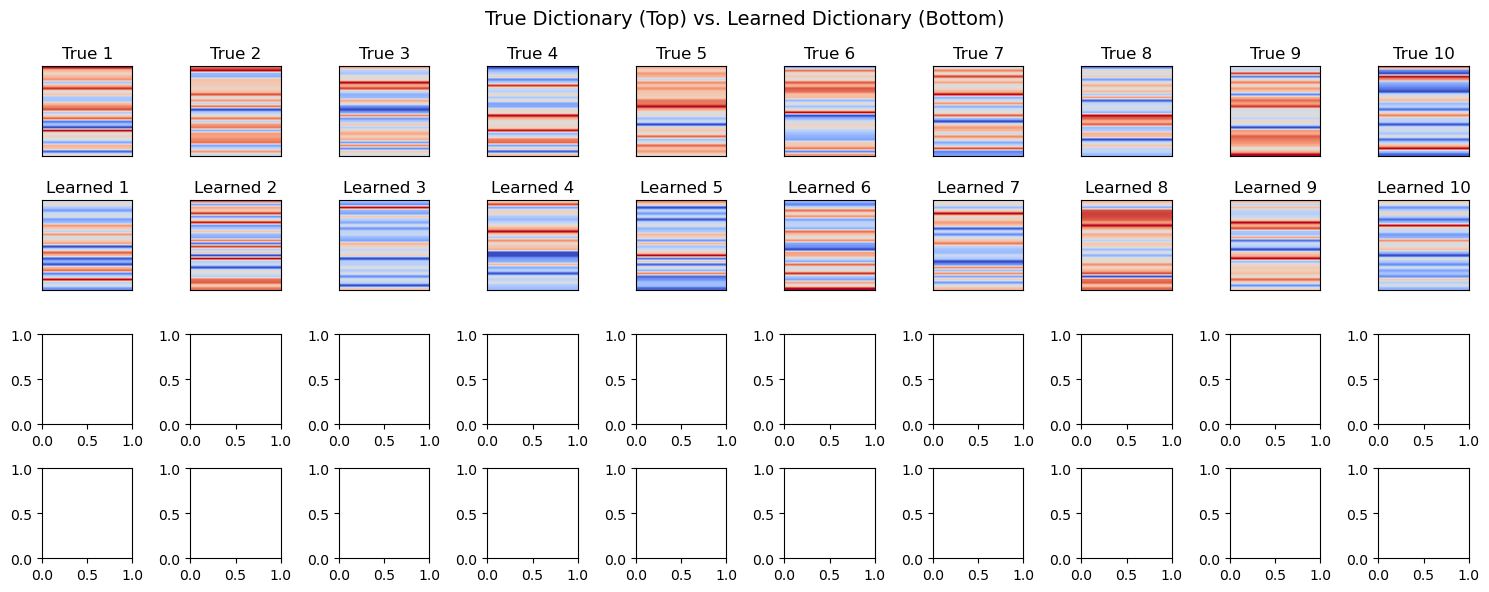

In [63]:
# Function to visualize dictionaries side by side for comparison
def plot_dictionary_comparison(true_dict, learned_dict):
    fig, axes = plt.subplots(4, 10, figsize=(15, 6))  # Adjusted grid for more atoms
    fig.suptitle("True Dictionary (Top) vs. Learned Dictionary (Bottom)", fontsize=14)

    for i in range(10):  # Show first 10 atoms for better visibility
        axes[0, i].imshow(true_dict[:, i].reshape(-1, 1), cmap="coolwarm", aspect="auto")
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        axes[0, i].set_title(f"True {i+1}")

        axes[1, i].imshow(learned_dict[:, i].reshape(-1, 1), cmap="coolwarm", aspect="auto")
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        axes[1, i].set_title(f"Learned {i+1}")

    plt.tight_layout()
    plt.show()

# Plot the comparison of the true dictionary and the learned dictionary
plot_dictionary_comparison(true_dictionary_np, learned_dictionary)

In [80]:
# Re-import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Define the sparse coding model with Langevin dynamics
class SparseCodingLangevin(nn.Module):
    def __init__(self, input_dim, num_basis, threshold_lambda=0.01, langevin_steps=10, eta=0.001):
        super(SparseCodingLangevin, self).__init__()

        # Dictionary (D) with smaller initialization for stability
        self.dictionary = nn.Parameter(torch.randn(num_basis, input_dim) * 0.01)

        # Learnable threshold controlling sparsity
        self.threshold_lambda = nn.Parameter(torch.tensor(threshold_lambda))

        # Langevin parameters
        self.langevin_steps = langevin_steps
        self.eta = eta  # Langevin step size

    def forward(self, x):
        # Step 1: Compute dense codes (initialization)
        s = torch.matmul(x, self.dictionary.T)

        # Step 2: Perform Langevin Sampling
        for _ in range(self.langevin_steps):
            noise = torch.randn_like(s)  # Gaussian noise
            grad = torch.sign(s) * torch.relu(torch.abs(s) - self.threshold_lambda)  # Soft-thresholding gradient
            s = s - self.eta * grad + torch.sqrt(torch.tensor(2 * self.eta, device=s.device)) * noise  # Fixed Langevin update

        # Step 3: Reconstruct the input
        reconstruction = torch.matmul(s, self.dictionary)

        return reconstruction, s

# Loss function with L1 regularization
def reconstruction_loss(reconstruction, original_data, sparse_codes, l1_lambda=0.001):
    mse_loss = nn.MSELoss()(reconstruction, original_data)
    l1_loss = l1_lambda * torch.mean(torch.abs(sparse_codes))  # L1 regularization
    return mse_loss, mse_loss + l1_loss

# Training function
def train_sparse_coding(data, input_dim=3072, num_basis=500, threshold_lambda=0.01, epochs=100, lr=0.0001, l1_lambda=0.0001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SparseCodingLangevin(input_dim, num_basis, threshold_lambda).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    mse_losses = []

    for epoch in range(epochs):
        total_mse_loss = 0

        with tqdm(total=len(data), desc=f'Epoch {epoch+1}/{epochs}', unit='batch') as pbar:
            for batch in data:
                batch = batch[0].view(batch[0].size(0), -1).to(device)  # Flatten images and move to GPU
                optimizer.zero_grad()

                # Forward pass
                reconstruction, sparse_codes = model(batch)

                # Compute loss
                mse_loss, total_loss = reconstruction_loss(reconstruction, batch, sparse_codes, l1_lambda)

                # Backpropagation
                total_loss.backward()
                optimizer.step()

                # Normalize dictionary atoms
                with torch.no_grad():
                    model.dictionary.data /= torch.norm(model.dictionary, dim=1, keepdim=True) + 1e-8

                total_mse_loss += mse_loss.item() * batch.size(0)  # Track MSE loss

                pbar.set_postfix(MSE_Loss=f'{mse_loss.item():.4f}')
                pbar.update(batch.size(0))

        # Log average loss per epoch
        avg_mse_loss = total_mse_loss / len(data.dataset)
        mse_losses.append(avg_mse_loss)

    return model, mse_losses

# Load CIFAR-10 dataset
def load_cifar10():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
    return trainloader

# Train the model
trainloader = load_cifar10()
trained_model, mse_losses = train_sparse_coding(trainloader)

Files already downloaded and verified


Epoch 1/100: 50000batch [00:09, 5373.86batch/s, MSE_Loss=0.0432]        
Epoch 2/100: 50000batch [00:09, 5338.73batch/s, MSE_Loss=0.0313]        
Epoch 3/100: 38656batch [00:05, 6452.99batch/s, MSE_Loss=0.0270]        


KeyboardInterrupt: 

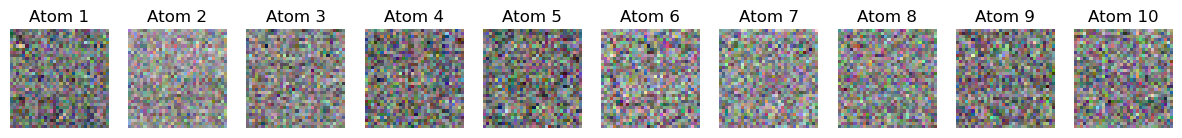

In [77]:
# Function to visualize learned dictionary atoms
def plot_learned_dictionary(dictionary, num_atoms=10, image_size=(32, 32, 3)):
    dictionary = dictionary.detach().cpu().numpy()  # Convert to NumPy for visualization
    fig, axes = plt.subplots(1, num_atoms, figsize=(15, 3))

    for i in range(num_atoms):
        atom = dictionary[i].reshape(image_size)  # Reshape each dictionary atom into image size
        atom = (atom - atom.min()) / (atom.max() - atom.min())  # Normalize for visualization

        axes[i].imshow(atom)
        axes[i].axis("off")
        axes[i].set_title(f"Atom {i+1}")

    plt.show()

# Retrieve learned dictionary from trained model
learned_dictionary = trained_model.dictionary

# Visualize learned dictionary atoms
plot_learned_dictionary(learned_dictionary, num_atoms=10, image_size=(32, 32, 3))

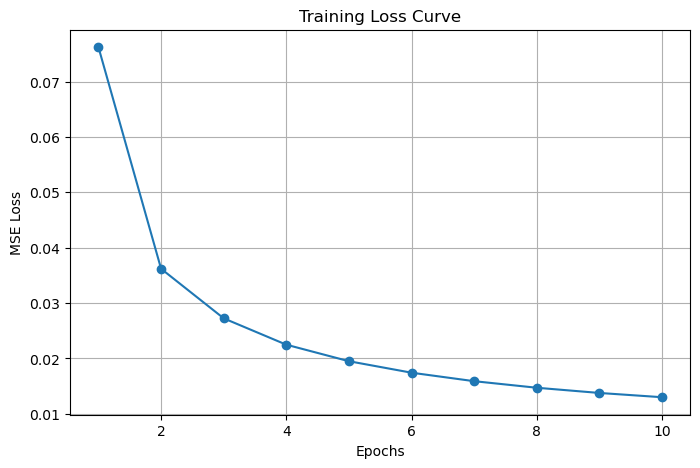

In [78]:
# Function to plot loss curves
def plot_loss_curve(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-')
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss Curve")
    plt.grid(True)
    plt.show()

# Plot the loss curve using stored MSE losses
plot_loss_curve(mse_losses)

Files already downloaded and verified


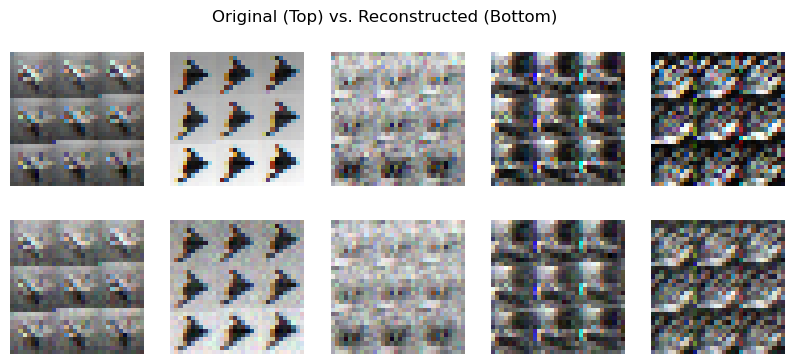

In [79]:
# Load CIFAR-10 test dataset
def load_cifar10_test():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=True)
    return testloader

# Function to evaluate dictionary performance on test images
def evaluate_dictionary_performance(model, testloader, num_samples=5):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get a batch of test images
    test_images, _ = next(iter(testloader))
    test_images = test_images.view(test_images.size(0), -1).to(device)  # Flatten images

    # Forward pass through the model
    with torch.no_grad():
        reconstructions, _ = model(test_images)

    # Convert images for visualization
    test_images = test_images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()

    # Display original vs reconstructed images
    fig, axes = plt.subplots(2, num_samples, figsize=(10, 4))
    fig.suptitle("Original (Top) vs. Reconstructed (Bottom)")

    for i in range(num_samples):
        # Original image
        orig_img = test_images[i].reshape(32, 32, 3)  # Reshape to image size
        orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())  # Normalize for display

        # Reconstructed image
        recon_img = reconstructions[i].reshape(32, 32, 3)  # Reshape to image size
        recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min())  # Normalize

        # Plot original
        axes[0, i].imshow(orig_img)
        axes[0, i].axis("off")

        # Plot reconstruction
        axes[1, i].imshow(recon_img)
        axes[1, i].axis("off")

    plt.show()

# Load test data
testloader = load_cifar10_test()

# Evaluate the learned dictionary performance on test images
evaluate_dictionary_performance(trained_model, testloader, num_samples=5)


In [81]:
# Re-import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Define the sparse coding model with Langevin dynamics
class SparseCodingLangevin(nn.Module):
    def __init__(self, input_dim, num_basis, threshold_lambda=0.01, langevin_steps=5, eta=0.001):
        super(SparseCodingLangevin, self).__init__()

        # Dictionary (D) with smaller initialization for stability
        self.dictionary = nn.Parameter(torch.randn(num_basis, input_dim) * 0.01)

        # Learnable threshold controlling sparsity
        self.threshold_lambda = nn.Parameter(torch.tensor(threshold_lambda))

        # Langevin parameters
        self.langevin_steps = langevin_steps
        self.eta = eta  # Langevin step size

    def forward(self, x):
        # Step 1: Compute dense codes (initialization)
        s = torch.matmul(x, self.dictionary.T)

        # Step 2: Perform Langevin Sampling
        for _ in range(self.langevin_steps):
            noise = torch.randn_like(s)  # Gaussian noise
            grad = torch.sign(s) * torch.relu(torch.abs(s) - self.threshold_lambda)  # Soft-thresholding gradient
            s = s - self.eta * grad + torch.sqrt(torch.tensor(2 * self.eta, device=s.device)) * noise  # Langevin update

        # Step 3: Reconstruct the input
        reconstruction = torch.matmul(s, self.dictionary)

        return reconstruction, s

# Loss function with L1 regularization
def reconstruction_loss(reconstruction, original_data, sparse_codes, l1_lambda=0.001):
    mse_loss = nn.MSELoss()(reconstruction, original_data)
    l1_loss = l1_lambda * torch.mean(torch.abs(sparse_codes))  # L1 regularization
    return mse_loss, mse_loss + l1_loss

# Training function
def train_sparse_coding(data, input_dim=3072, num_basis=1000, threshold_lambda=0.01, epochs=20, lr=0.0001, l1_lambda=0.0001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SparseCodingLangevin(input_dim, num_basis, threshold_lambda).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    mse_losses = []

    for epoch in range(epochs):
        total_mse_loss = 0

        with tqdm(total=len(data), desc=f'Epoch {epoch+1}/{epochs}', unit='batch') as pbar:
            for batch in data:
                batch = batch[0].view(batch[0].size(0), -1).to(device)  # Flatten images and move to GPU
                optimizer.zero_grad()

                # Forward pass
                reconstruction, sparse_codes = model(batch)

                # Compute loss
                mse_loss, total_loss = reconstruction_loss(reconstruction, batch, sparse_codes, l1_lambda)

                # Backpropagation
                total_loss.backward()
                optimizer.step()

                # Normalize dictionary atoms
                with torch.no_grad():
                    model.dictionary.data /= torch.norm(model.dictionary, dim=1, keepdim=True) + 1e-8

                total_mse_loss += mse_loss.item() * batch.size(0)  # Track MSE loss

                pbar.set_postfix(MSE_Loss=f'{mse_loss.item():.4f}')
                pbar.update(batch.size(0))

        # Log average loss per epoch
        avg_mse_loss = total_mse_loss / len(data.dataset)
        mse_losses.append(avg_mse_loss)

    return model, mse_losses

# Load CIFAR-10 training dataset
def load_cifar10_train():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
    return trainloader

# Train the model on CIFAR-10
trainloader = load_cifar10_train()
trained_model, mse_losses = train_sparse_coding(trainloader)


Files already downloaded and verified


Epoch 1/20: 50000batch [00:08, 5967.21batch/s, MSE_Loss=0.0293]        
Epoch 2/20: 50000batch [00:08, 6076.56batch/s, MSE_Loss=0.0195]        
Epoch 3/20: 50000batch [00:08, 6160.66batch/s, MSE_Loss=0.0151]        
Epoch 4/20: 50000batch [00:08, 6158.26batch/s, MSE_Loss=0.0133]        
Epoch 5/20: 50000batch [00:08, 6064.47batch/s, MSE_Loss=0.0116]        
Epoch 6/20: 50000batch [00:08, 6021.46batch/s, MSE_Loss=0.0106]        
Epoch 7/20: 50000batch [00:08, 5977.32batch/s, MSE_Loss=0.0101]        
Epoch 8/20: 50000batch [00:08, 6205.57batch/s, MSE_Loss=0.0092]        
Epoch 9/20: 50000batch [00:08, 6166.92batch/s, MSE_Loss=0.0088]        
Epoch 10/20: 50000batch [00:07, 6255.78batch/s, MSE_Loss=0.0079]        
Epoch 11/20: 50000batch [00:08, 6192.58batch/s, MSE_Loss=0.0073]        
Epoch 12/20: 50000batch [00:08, 6247.71batch/s, MSE_Loss=0.0069]        
Epoch 13/20: 50000batch [00:08, 6239.73batch/s, MSE_Loss=0.0066]        
Epoch 14/20: 50000batch [00:08, 6098.90batch/s, MSE_Loss=0.0

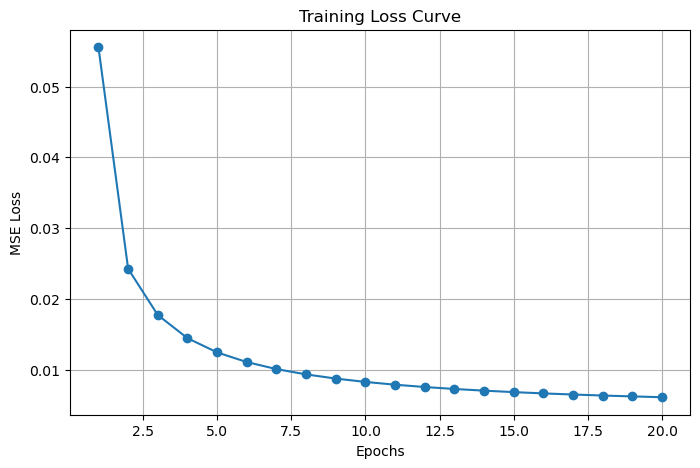

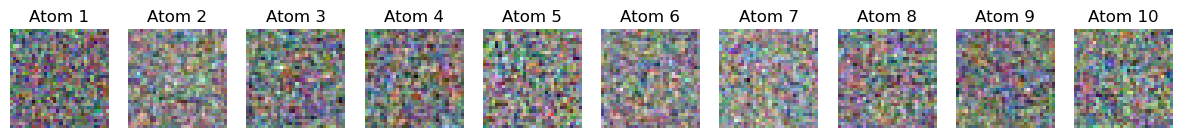

Files already downloaded and verified


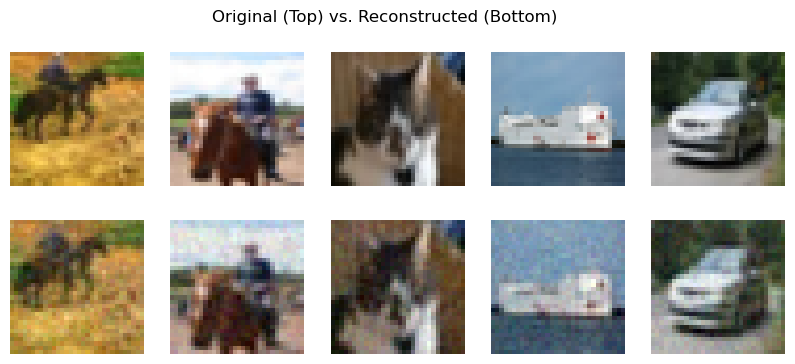

In [95]:
# Function to plot loss curve
def plot_loss_curve(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-')
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss Curve")
    plt.grid(True)
    plt.show()

# Plot the loss curve
plot_loss_curve(mse_losses)

# Function to visualize learned dictionary atoms
def plot_learned_dictionary(dictionary, num_atoms=10, image_size=(32, 32, 3)):
    dictionary = dictionary.detach().cpu().numpy()  # Convert to NumPy for visualization
    fig, axes = plt.subplots(1, num_atoms, figsize=(15, 3))

    for i in range(num_atoms):
        atom = dictionary[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape each dictionary atom into image size
        atom = (atom - atom.min()) / (atom.max() - atom.min())  # Normalize for visualization

        axes[i].imshow(atom)
        axes[i].axis("off")
        axes[i].set_title(f"Atom {i+1}")

    plt.show()

# Retrieve learned dictionary from trained model
learned_dictionary = trained_model.dictionary

# Visualize learned dictionary atoms
plot_learned_dictionary(learned_dictionary, num_atoms=10, image_size=(32, 32, 3))

# Load CIFAR-10 test dataset
def load_cifar10_test():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=True)
    return testloader

# Function to evaluate dictionary performance on test images
def evaluate_dictionary_performance(model, testloader, num_samples=5):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get a batch of test images
    test_images, _ = next(iter(testloader))
    test_images = test_images.view(test_images.size(0), -1).to(device)  # Flatten images

    # Forward pass through the model
    with torch.no_grad():
        reconstructions, _ = model(test_images)

    # Convert images for visualization
    test_images = test_images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()

    # Display original vs reconstructed images
    fig, axes = plt.subplots(2, num_samples, figsize=(10, 4))
    fig.suptitle("Original (Top) vs. Reconstructed (Bottom)")

    for i in range(num_samples):
        # Original image
        orig_img = test_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
        orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())  # Normalize for display

        # Reconstructed image
        recon_img = reconstructions[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
        recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min())  # Normalize

        # Plot original
        axes[0, i].imshow(orig_img)
        axes[0, i].axis("off")

        # Plot reconstruction
        axes[1, i].imshow(recon_img)
        axes[1, i].axis("off")

    plt.show()

# Load test data
testloader = load_cifar10_test()

# Evaluate the learned dictionary performance on test images
evaluate_dictionary_performance(trained_model, testloader, num_samples=5)


Files already downloaded and verified


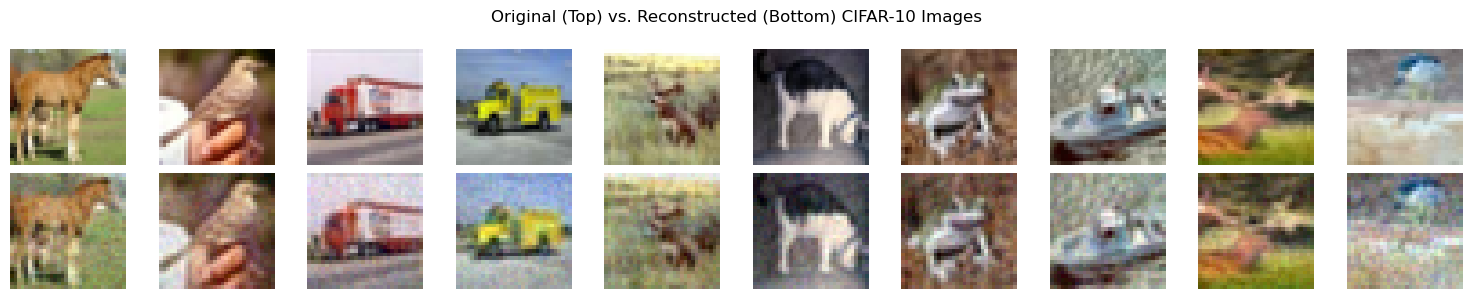

In [96]:
# Function to visualize original and reconstructed CIFAR-10 images
def visualize_reconstructed_images(model, testloader, num_samples=10):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get a batch of test images
    test_images, _ = next(iter(testloader))
    test_images = test_images.view(test_images.size(0), -1).to(device)  # Flatten images

    # Forward pass through the model
    with torch.no_grad():
        reconstructions, _ = model(test_images)

    # Convert images for visualization
    test_images = test_images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()

    # Display original vs reconstructed images
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 3))
    fig.suptitle("Original (Top) vs. Reconstructed (Bottom) CIFAR-10 Images")

    for i in range(num_samples):
        # Original image
        orig_img = test_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
        orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())  # Normalize for display

        # Reconstructed image
        recon_img = reconstructions[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
        recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min())  # Normalize

        # Plot original
        axes[0, i].imshow(orig_img)
        axes[0, i].axis("off")

        # Plot reconstruction
        axes[1, i].imshow(recon_img)
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

# Load CIFAR-10 test dataset
def load_cifar10_test():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=True)
    return testloader

# Load test data
testloader = load_cifar10_test()

# Visualize original vs reconstructed CIFAR-10 images
visualize_reconstructed_images(trained_model, testloader, num_samples=10)

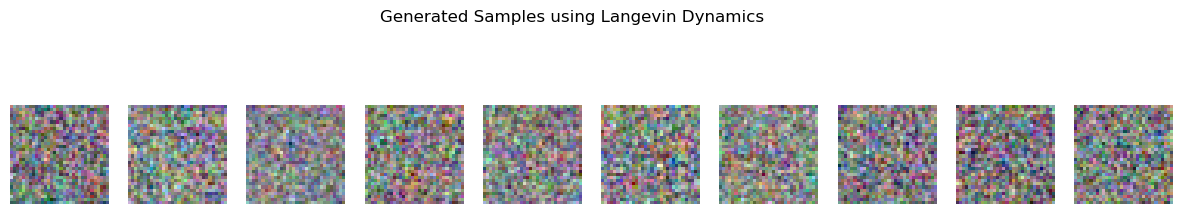

In [97]:
# Function to generate structured sparse codes using Langevin dynamics
def sample_structured_sparse_codes(model, num_samples=10, langevin_steps=1000, eta=0.001, image_size=(32, 32, 3)):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Initialize sparse codes randomly
    with torch.no_grad():
        sparse_codes = torch.randn(num_samples, model.dictionary.shape[0], device=device)

        # Langevin dynamics updates
        for _ in range(langevin_steps):
            noise = torch.randn_like(sparse_codes)  # Gaussian noise
            grad = torch.sign(sparse_codes) * torch.relu(torch.abs(sparse_codes) - model.threshold_lambda)  # Soft-thresholding gradient
            sparse_codes = sparse_codes - eta * grad + torch.sqrt(torch.tensor(2 * eta, device=device)) * noise  # Langevin update

        # Generate images using the learned dictionary
        generated_images = torch.matmul(sparse_codes, model.dictionary)

    # Convert images for visualization
    generated_images = generated_images.cpu().numpy()

    # Display generated images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle("Generated Samples using Langevin Dynamics")

    for i in range(num_samples):
        gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
        gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize

        axes[i].imshow(gen_img)
        axes[i].axis("off")

    plt.show()

# Perform structured sampling using Langevin dynamics
sample_structured_sparse_codes(trained_model, num_samples=10, langevin_steps=1000, eta=0.001, image_size=(32, 32, 3))

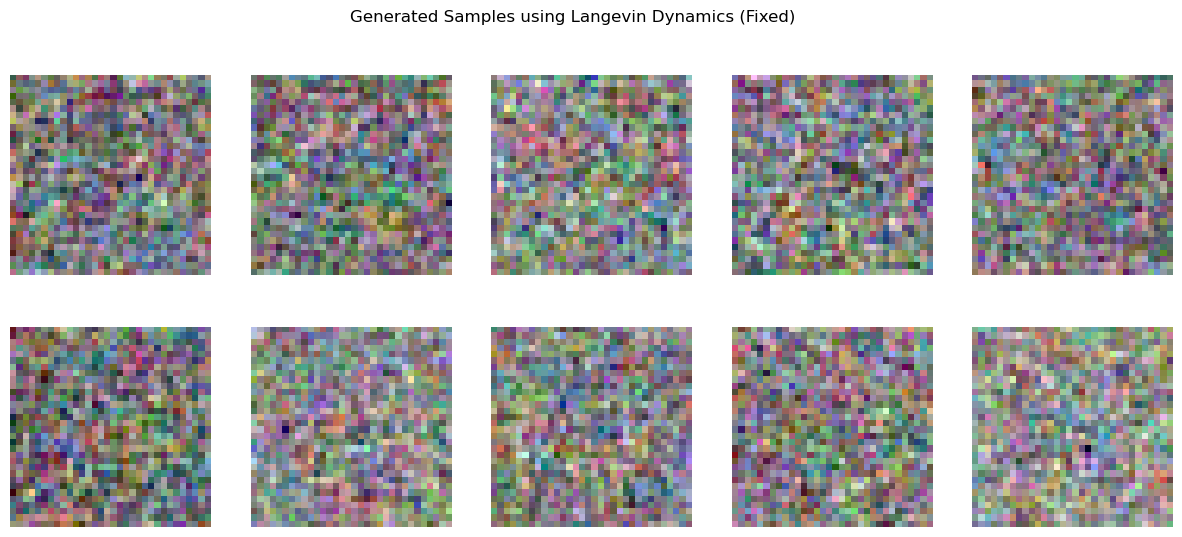

In [98]:
# Function to generate structured sparse codes using Langevin dynamics and plot correctly
def sample_structured_sparse_codes_fixed(model, num_samples=10, langevin_steps=10, eta=0.001, image_size=(32, 32, 3)):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Initialize sparse codes randomly
    with torch.no_grad():
        sparse_codes = torch.randn(num_samples, model.dictionary.shape[0], device=device)

        # Langevin dynamics updates
        for _ in range(langevin_steps):
            noise = torch.randn_like(sparse_codes)  # Gaussian noise
            grad = torch.sign(sparse_codes) * torch.relu(torch.abs(sparse_codes) - model.threshold_lambda)  # Soft-thresholding gradient
            sparse_codes = sparse_codes - eta * grad + torch.sqrt(torch.tensor(2 * eta, device=device)) * noise  # Langevin update

        # Generate images using the learned dictionary
        generated_images = torch.matmul(sparse_codes, model.dictionary)

    # Convert images for visualization
    generated_images = generated_images.cpu().numpy()

    # Display generated images in a 2-row grid
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    fig.suptitle("Generated Samples using Langevin Dynamics (Fixed)")

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Reshape to image size
            gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize
            ax.imshow(gen_img)
            ax.axis("off")

    plt.show()

# Perform structured sampling using Langevin dynamics (with fixed plotting)
sample_structured_sparse_codes_fixed(trained_model, num_samples=10, langevin_steps=10, eta=0.001, image_size=(32, 32, 3))


Files already downloaded and verified


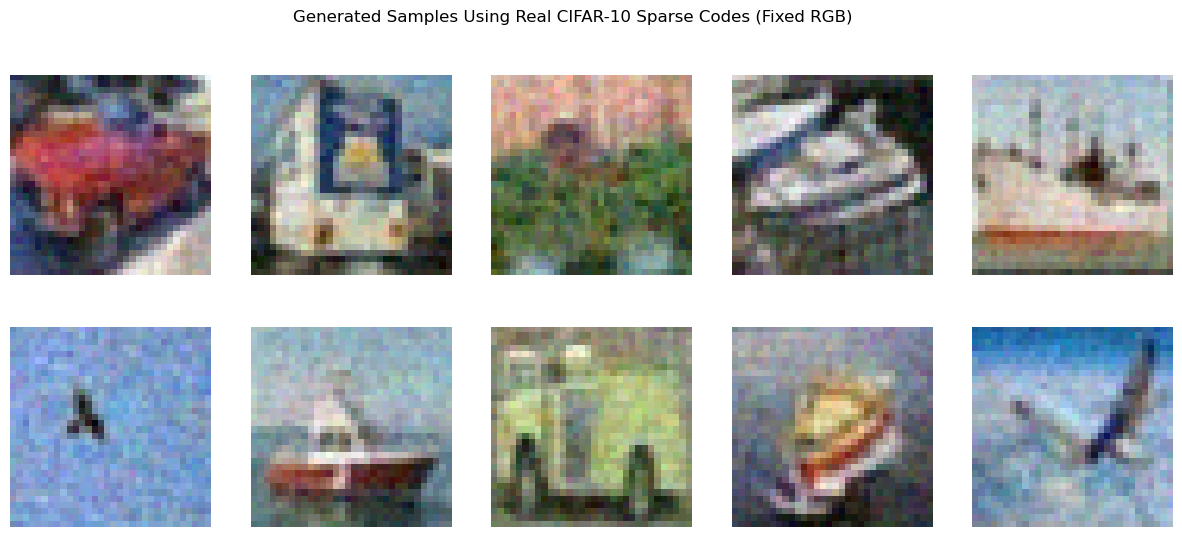

In [99]:
# Function to generate structured sparse codes using Langevin dynamics with proper RGB shaping
def sample_structured_sparse_codes_fixed_rgb(model, testloader, num_samples=10, langevin_steps=10, eta=0.001):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get a batch of test images
    test_images, _ = next(iter(testloader))
    test_images = test_images.view(test_images.size(0), -1).to(device)  # Flatten images

    with torch.no_grad():
        # Encode images into sparse codes
        sparse_codes = torch.matmul(test_images, model.dictionary.T)

        # Apply Langevin dynamics to refine sparse codes
        for _ in range(langevin_steps):
            noise = torch.randn_like(sparse_codes)  # Gaussian noise
            grad = torch.sign(sparse_codes) * torch.relu(torch.abs(sparse_codes) - model.threshold_lambda)  # Soft-thresholding gradient
            sparse_codes = sparse_codes - eta * grad + torch.sqrt(torch.tensor(2 * eta, device=device)) * noise  # Langevin update

        # Generate new images using the refined sparse codes
        generated_images = torch.matmul(sparse_codes, model.dictionary)

    # Convert images for visualization with correct RGB shape
    generated_images = generated_images.cpu().numpy()

    # Display generated images in a grid
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    fig.suptitle("Generated Samples Using Real CIFAR-10 Sparse Codes (Fixed RGB)")

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Convert (3, 32, 32) -> (32, 32, 3)
            gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize
            ax.imshow(gen_img)
            ax.axis("off")

    plt.show()

# Load CIFAR-10 test data
testloader = load_cifar10_test()

# Generate samples using real CIFAR-10 images as sparse code input (Fixed RGB)
sample_structured_sparse_codes_fixed_rgb(trained_model, testloader, num_samples=10, langevin_steps=10, eta=0.001)

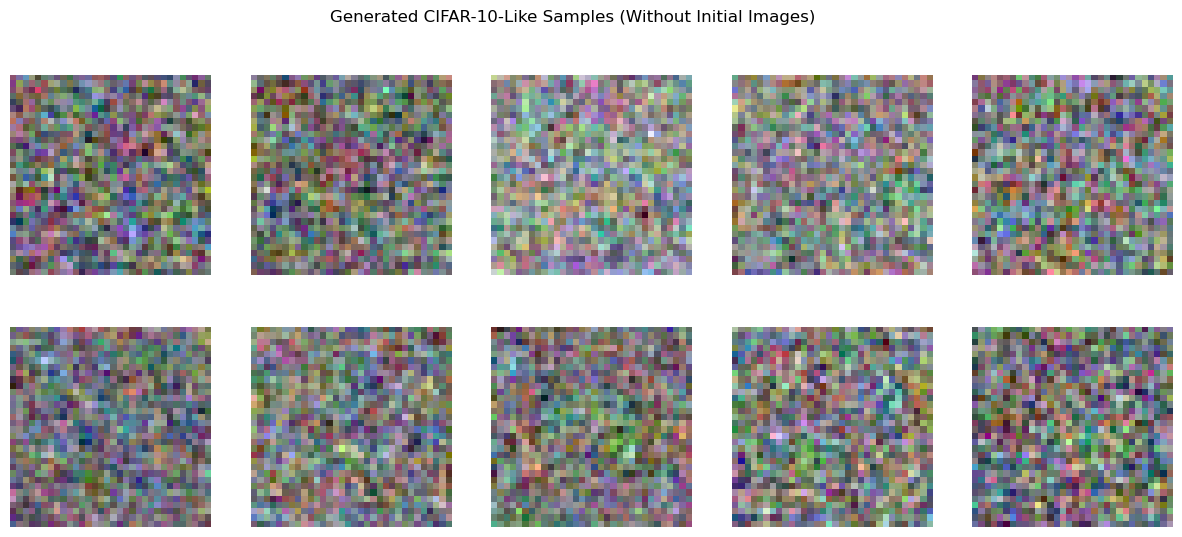

In [102]:
# Function to generate CIFAR-10-like images using Langevin dynamics without initial images
def generate_cifar10_like_images(model, num_samples=10, langevin_steps=50, eta=0.001, image_size=(32, 32, 3)):
    """
    Generates CIFAR-10-like images using Langevin dynamics without initial images.

    Args:
    - model: Trained sparse coding model
    - num_samples: Number of images to generate
    - langevin_steps: Number of Langevin sampling steps
    - eta: Langevin step size

    Returns:
    - Generated images
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Initialize sparse codes from a Gaussian prior
    with torch.no_grad():
        sparse_codes = torch.randn(num_samples, model.dictionary.shape[0], device=device)

        # Langevin dynamics refinement
        for _ in range(langevin_steps):
            noise = torch.randn_like(sparse_codes)  # Gaussian noise
            grad = torch.sign(sparse_codes) * torch.relu(torch.abs(sparse_codes) - model.threshold_lambda)  # Soft-thresholding gradient
            sparse_codes = sparse_codes - eta * grad + torch.sqrt(torch.tensor(2 * eta, device=device)) * noise  # Langevin update

        # Generate images using the refined sparse codes
        generated_images = torch.matmul(sparse_codes, model.dictionary)

    # Convert images for visualization with correct RGB shape
    generated_images = generated_images.cpu().numpy()

    # Display generated images in a grid
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    fig.suptitle("Generated CIFAR-10-Like Samples (Without Initial Images)")

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Convert (3, 32, 32) -> (32, 32, 3)
            gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize
            ax.imshow(gen_img)
            ax.axis("off")

    plt.show()

# Generate CIFAR-10-like images using Langevin sampling without initial images
generate_cifar10_like_images(trained_model, num_samples=10, langevin_steps=500, eta=0.001, image_size=(32, 32, 3))

Files already downloaded and verified
Epoch [1/10], Loss: 0.6103
Epoch [2/10], Loss: 0.5714
Epoch [3/10], Loss: 0.5370
Epoch [4/10], Loss: 0.5157
Epoch [5/10], Loss: 0.5050
Epoch [6/10], Loss: 0.5018
Epoch [7/10], Loss: 0.5007
Epoch [8/10], Loss: 0.4968
Epoch [9/10], Loss: 0.4899
Epoch [10/10], Loss: 0.4875


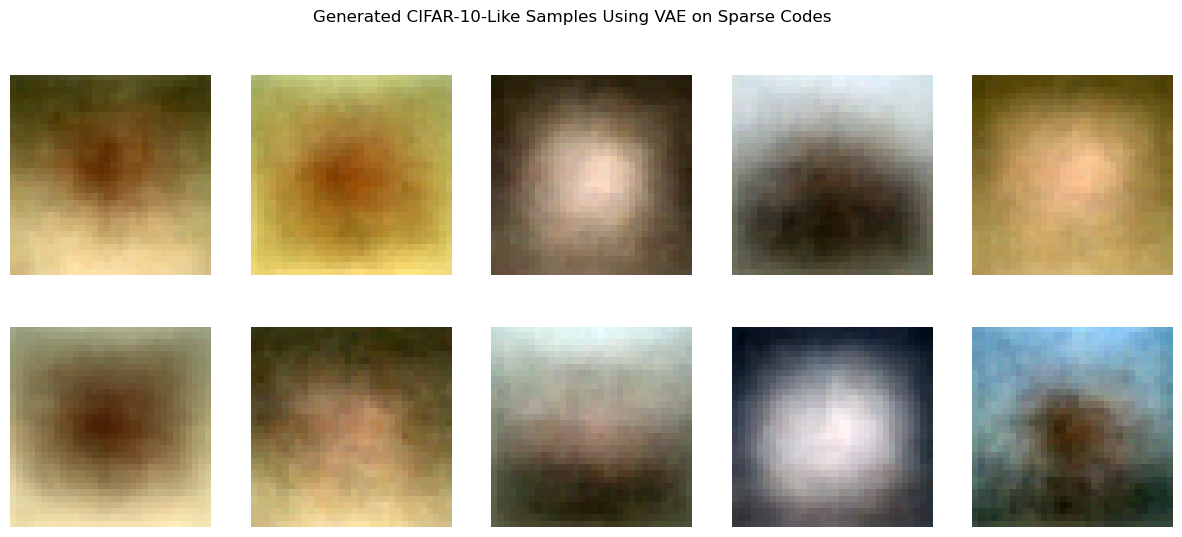

In [103]:
# Define the Variational Autoencoder (VAE) for sparse code learning
class VAE(nn.Module):
    def __init__(self, latent_dim, sparse_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.sparse_dim = sparse_dim

        # Encoder: Maps sparse codes to latent space
        self.encoder = nn.Sequential(
            nn.Linear(sparse_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        # Mean and log variance layers for latent space
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder: Maps latent space back to sparse codes
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, sparse_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# VAE Loss Function (Reconstruction + KL Divergence)
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)  # Reconstruction loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence loss
    return recon_loss + 0.001 * kl_loss  # Weight KL loss to balance

# Train the VAE on sparse codes
def train_vae(trainloader, dictionary, latent_dim=128, sparse_dim=1000, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VAE(latent_dim, sparse_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in trainloader:
            images, _ = batch
            images = images.view(images.size(0), -1).to(device)  # Flatten images

            # Encode images into sparse codes
            with torch.no_grad():
                sparse_codes = torch.matmul(images, dictionary.T.to(device))

            optimizer.zero_grad()
            recon_sparse, mu, logvar = model(sparse_codes)
            loss = vae_loss(recon_sparse, sparse_codes, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(trainloader):.4f}")

    return model

# Function to generate CIFAR-10-like images using the VAE learned prior
def generate_images_from_vae(model, dictionary, num_samples=10, image_size=(32, 32, 3)):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        # Sample from learned latent space
        z = torch.randn(num_samples, model.latent_dim, device=device)
        sparse_codes = model.decode(z)

        # Generate images using the learned dictionary
        generated_images = torch.matmul(sparse_codes, dictionary.to(device))

    # Convert images for visualization with correct RGB shape
    generated_images = generated_images.cpu().numpy()

    # Display generated images in a grid
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    fig.suptitle("Generated CIFAR-10-Like Samples Using VAE on Sparse Codes")

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Convert (3, 32, 32) -> (32, 32, 3)
            gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize
            ax.imshow(gen_img)
            ax.axis("off")

    plt.show()

# Load CIFAR-10 train data
trainloader = load_cifar10_test()  # Using test loader for quick training

# Train the VAE on sparse codes
vae_model = train_vae(trainloader, trained_model.dictionary, latent_dim=128, sparse_dim=trained_model.dictionary.shape[0], epochs=10, lr=0.001)

# Generate images using the VAE-learned prior on sparse codes
generate_images_from_vae(vae_model, trained_model.dictionary, num_samples=10, image_size=(32, 32, 3))


Files already downloaded and verified
Epoch [1/100], Loss: 1.1219
Epoch [2/100], Loss: 0.9447
Epoch [3/100], Loss: 0.8178
Epoch [4/100], Loss: 0.7069
Epoch [5/100], Loss: 0.6104
Epoch [6/100], Loss: 0.5257
Epoch [7/100], Loss: 0.4510
Epoch [8/100], Loss: 0.3846
Epoch [9/100], Loss: 0.3272
Epoch [10/100], Loss: 0.2773
Epoch [11/100], Loss: 0.2356
Epoch [12/100], Loss: 0.2001
Epoch [13/100], Loss: 0.1707
Epoch [14/100], Loss: 0.1469
Epoch [15/100], Loss: 0.1279
Epoch [16/100], Loss: 0.1131
Epoch [17/100], Loss: 0.1019
Epoch [18/100], Loss: 0.0936
Epoch [19/100], Loss: 0.0876
Epoch [20/100], Loss: 0.0834
Epoch [21/100], Loss: 0.0805
Epoch [22/100], Loss: 0.0784
Epoch [23/100], Loss: 0.0772
Epoch [24/100], Loss: 0.0761
Epoch [25/100], Loss: 0.0755
Epoch [26/100], Loss: 0.0750
Epoch [27/100], Loss: 0.0747
Epoch [28/100], Loss: 0.0743
Epoch [29/100], Loss: 0.0741
Epoch [30/100], Loss: 0.0738
Epoch [31/100], Loss: 0.0736
Epoch [32/100], Loss: 0.0733
Epoch [33/100], Loss: 0.0732
Epoch [34/100]

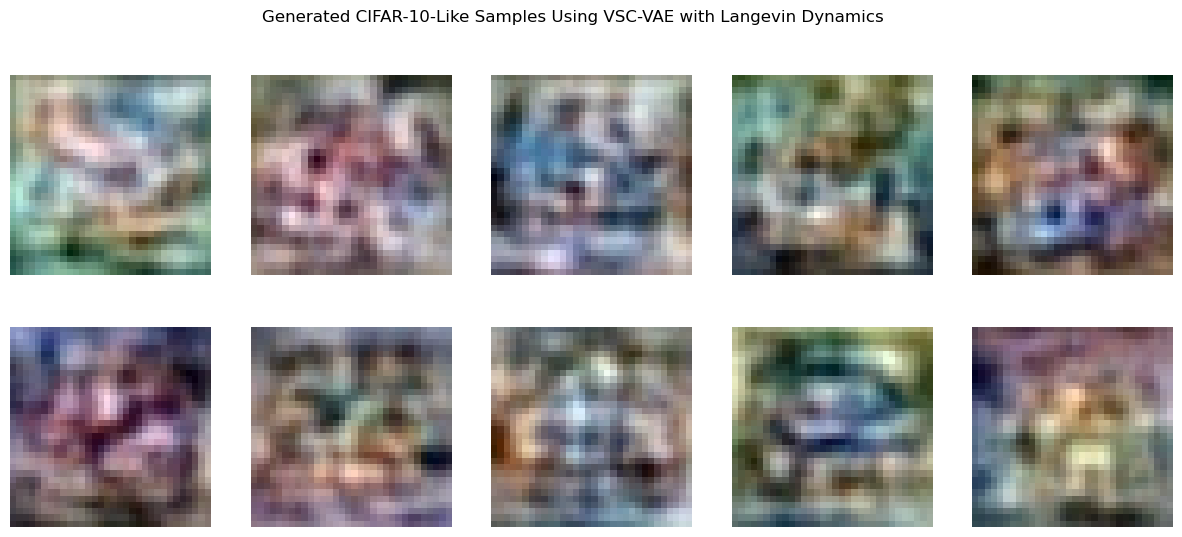

In [111]:
# Define the Variational Sparse Coding (VSC) model with Langevin dynamics (Fixed Shape)
class VSCVAE_Langevin(nn.Module):
    def __init__(self, input_dim, dictionary_atoms, langevin_steps=100, eta=0.001):
        super(VSCVAE_Langevin, self).__init__()
        self.latent_dim = dictionary_atoms  # Ensure latent_dim matches dictionary_atoms
        self.dictionary_atoms = dictionary_atoms
        self.langevin_steps = langevin_steps  # Langevin sampling steps
        self.eta = eta  # Langevin step size

        # Encoder: Maps input images to latent sparse codes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, dictionary_atoms)  # Now output matches dictionary atoms
        )

        # Dictionary (D) for decoding sparse codes into images
        self.dictionary = nn.Parameter(torch.randn(dictionary_atoms, input_dim) * 0.1)

    def encode(self, x):
        return self.encoder(x)

    def reparameterize(self, z):
        # Apply Langevin dynamics refinement on latent codes
        for _ in range(self.langevin_steps):
            noise = torch.randn_like(z)  # Gaussian noise
            grad = torch.sign(z) * torch.relu(torch.abs(z) - 0.1)  # Soft-thresholding gradient for sparsity
            z = z - self.eta * grad + torch.sqrt(torch.tensor(2 * self.eta, device=z.device)) * noise  # Langevin update

        return z

    def decode(self, sparse_codes):
        return torch.matmul(sparse_codes, self.dictionary)  # Reconstruction using sparse codes

    def forward(self, x):
        sparse_codes = self.encode(x)  # Now directly infer sparse codes
        sparse_codes = self.reparameterize(sparse_codes)  # Apply Langevin refinement
        recon_x = self.decode(sparse_codes)
        return recon_x, sparse_codes

# VSC Loss Function (Sparse Coding + L1 Regularization)
def vsc_vae_loss(recon_x, x, sparse_codes, lambda_sparsity=0.1):
    recon_loss = nn.MSELoss()(recon_x, x)  # Reconstruction loss
    sparsity_loss = lambda_sparsity * torch.mean(torch.abs(sparse_codes))  # Enforce sparsity (L1 penalty)
    return recon_loss + sparsity_loss  # Weighted sparsity

# Train the VSC-VAE model with Langevin refinement (Fixed)
def train_vsc_vae(trainloader, input_dim, dictionary_atoms, epochs=10, lr=0.001, langevin_steps=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VSCVAE_Langevin(input_dim, dictionary_atoms, langevin_steps=langevin_steps).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in trainloader:
            images, _ = batch
            images = images.view(images.size(0), -1).to(device)  # Flatten images

            optimizer.zero_grad()
            recon_x, sparse_codes = model(images)
            loss = vsc_vae_loss(recon_x, images, sparse_codes, lambda_sparsity=0.1)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(trainloader):.4f}")

    return model

# Function to generate CIFAR-10-like images using the VSC model with Langevin refinement
def generate_images_from_vsc_vae(model, num_samples=10, image_size=(32, 32, 3)):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        # Sample from the learned sparse space
        sparse_codes = torch.randn(num_samples, model.latent_dim, device=device)
        sparse_codes = model.reparameterize(sparse_codes)  # Apply Langevin refinement

        # Generate images using the learned dictionary
        generated_images = torch.matmul(sparse_codes, model.dictionary)

    # Convert images for visualization with correct RGB shape
    generated_images = generated_images.cpu().numpy()

    # Display generated images in a grid
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    fig.suptitle("Generated CIFAR-10-Like Samples Using VSC-VAE with Langevin Dynamics")

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            gen_img = generated_images[i].reshape(3, 32, 32).transpose(1, 2, 0)  # Convert (3, 32, 32) -> (32, 32, 3)
            gen_img = (gen_img - gen_img.min()) / (gen_img.max() - gen_img.min())  # Normalize
            ax.imshow(gen_img)
            ax.axis("off")

    plt.show()

# Load CIFAR-10 train data
trainloader = load_cifar10_test()  # Using test loader for quick training

# Train the Variational Sparse Coding (VSC-VAE) model with Langevin refinement
vsc_vae_model = train_vsc_vae(trainloader, input_dim=3072, dictionary_atoms=1000, epochs=100, lr=0.0001, langevin_steps=50)

# Generate images using the VSC-VAE model
generate_images_from_vsc_vae(vsc_vae_model, num_samples=10, image_size=(32, 32, 3))

In [114]:
import torch
import torch.nn as nn
import torch.distributions as dist

class BayesianSparseCoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        # Dictionary with Gaussian priors
        self.D_mu = nn.Parameter(torch.randn(input_dim, latent_dim))
        self.D_rho = nn.Parameter(torch.randn(input_dim, latent_dim))

        # Spike-and-slab prior for x
        self.x_mu = nn.Parameter(torch.randn(latent_dim))
        self.x_rho = nn.Parameter(torch.randn(latent_dim))
        self.spike_prob = nn.Parameter(torch.randn(latent_dim))  # Logits for spike probability

    def reparameterize(self, mu, rho):
        eps = torch.randn_like(mu)
        return mu + torch.log1p(torch.exp(rho)) * eps  # Softplus for std

    def forward(self, y):
        # Sample dictionary and codes
        D = self.reparameterize(self.D_mu, self.D_rho)
        x_mu = self.reparameterize(self.x_mu, self.x_rho)
        spike = dist.Bernoulli(logits=self.spike_prob).sample()
        x = x_mu * spike  # Spike-and-slab: zero out some dimensions

        # Reconstruction
        y_recon = D @ x
        return y_recon, x

    def loss(self, y, y_recon, x):
        # KL divergence for D and x
        kl_D = -0.5 * (1 + 2 * torch.log(torch.log1p(torch.exp(self.D_rho))) - self.D_mu ** 2 - torch.log1p(torch.exp(2 * self.D_rho))).sum()
        kl_x = dist.KLDivergence(dist.Laplace(x, 1.0), dist.Normal(0, 1.0)).sum()
        # Reconstruction loss
        recon_loss = dist.Normal(y_recon, 1.0).log_prob(y).sum()
        return -(recon_loss - kl_D - kl_x)

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as dist
import numpy as np

class SpikeAndSlabSparseCoding(nn.Module):
    def __init__(self, input_dim, dict_size, pi=0.1, sigma=1.0, tau=1.0):
        """
        Sparse Coding with Spike-and-Slab prior

        Args:
            input_dim: Dimension of input data
            dict_size: Number of dictionary elements
            pi: Prior probability of a coefficient being non-zero (sparsity parameter)
            sigma: Standard deviation of observation noise
            tau: Standard deviation of the slab component
        """
        super(SpikeAndSlabSparseCoding, self).__init__()

        # Initialize dictionary matrix
        self.dictionary = nn.Parameter(torch.randn(dict_size, input_dim) / np.sqrt(input_dim))
        self.normalize_dictionary()

        # Model parameters
        self.pi = pi  # Probability of activation
        self.sigma = sigma  # Observation noise
        self.tau = tau  # Slab width

        # Variational parameters
        self.register_buffer('phi_logit', torch.zeros(1))  # For binary indicators

    def normalize_dictionary(self):
        """Normalize dictionary atoms to have unit L2 norm"""
        with torch.no_grad():
            norms = torch.norm(self.dictionary, dim=1, keepdim=True)
            self.dictionary.data = self.dictionary.data / norms

    def encode(self, x, num_iterations=100, learning_rate=0.01):
        """
        Infer sparse coefficients using variational inference

        Args:
            x: Input data tensor of shape (batch_size, input_dim)
            num_iterations: Number of optimization iterations
            learning_rate: Learning rate for optimization

        Returns:
            Tuple of (coefficients_mean, coefficients_logvar, activation_probs)
        """
        batch_size = x.shape[0]
        dict_size = self.dictionary.shape[0]

        # Initialize variational parameters
        coef_mean = nn.Parameter(torch.zeros(batch_size, dict_size, device=x.device))
        coef_logvar = nn.Parameter(torch.zeros(batch_size, dict_size, device=x.device))
        activation_logits = nn.Parameter(torch.zeros(batch_size, dict_size, device=x.device))

        optimizer = optim.Adam([coef_mean, coef_logvar, activation_logits], lr=learning_rate)

        for _ in range(num_iterations):
            optimizer.zero_grad()

            # Compute activation probabilities
            activation_probs = torch.sigmoid(activation_logits)

            # Sample coefficients using reparameterization trick
            epsilon = torch.randn_like(coef_mean)
            coef_std = torch.exp(0.5 * coef_logvar)
            coefficients = coef_mean + epsilon * coef_std

            # Reconstruction error term
            reconstruction = torch.mm(coefficients, self.dictionary)
            recon_error = 0.5 / (self.sigma ** 2) * torch.sum((x - reconstruction) ** 2)

            # KL divergence for continuous part (slab)
            kl_continuous = -0.5 * torch.sum(
                1 + coef_logvar - coef_mean.pow(2) - coef_logvar.exp()
            )

            # KL divergence for binary part (spike)
            kl_binary = torch.sum(
                activation_probs * torch.log(activation_probs / self.pi + 1e-10) +
                (1 - activation_probs) * torch.log((1 - activation_probs) / (1 - self.pi) + 1e-10)
            )

            # Total loss (negative ELBO)
            loss = recon_error + kl_continuous + kl_binary
            loss.backward()
            optimizer.step()

        return coef_mean.detach(), coef_logvar.detach(), activation_probs.detach()

    def forward(self, x):
        """
        Forward pass: encode input and reconstruct

        Args:
            x: Input data tensor of shape (batch_size, input_dim)

        Returns:
            Tuple of (reconstructed_data, coefficients_mean, activation_probs)
        """
        coef_mean, _, activation_probs = self.encode(x)
        # Use MAP estimate (mean * activation probability)
        coefficients = coef_mean * activation_probs
        reconstruction = torch.mm(coefficients, self.dictionary)
        return reconstruction, coefficients, activation_probs

    def fit(self, dataloader, num_epochs=10, learning_rate=0.001):
        """
        Learn dictionary from data using variational EM

        Args:
            dataloader: PyTorch DataLoader containing training data
            num_epochs: Number of training epochs
            learning_rate: Learning rate for dictionary update
        """
        optimizer = optim.Adam([self.dictionary], lr=learning_rate)

        for epoch in range(num_epochs):
            total_loss = 0
            for batch in dataloader:
                if isinstance(batch, (tuple, list)):
                    batch = batch[0]

                optimizer.zero_grad()

                # E-step: Get variational parameters
                coef_mean, coef_logvar, activation_probs = self.encode(batch)

                # Sample coefficients
                epsilon = torch.randn_like(coef_mean)
                coef_std = torch.exp(0.5 * coef_logvar)
                coefficients = coef_mean + epsilon * coef_std

                # M-step: Update dictionary
                reconstruction = torch.mm(coefficients * activation_probs, self.dictionary)
                recon_error = 0.5 / (self.sigma ** 2) * torch.sum((batch - reconstruction) ** 2)

                # KL divergences
                kl_continuous = -0.5 * torch.sum(
                    1 + coef_logvar - coef_mean.pow(2) - coef_logvar.exp()
                )
                kl_binary = torch.sum(
                    activation_probs * torch.log(activation_probs / self.pi + 1e-10) +
                    (1 - activation_probs) * torch.log((1 - activation_probs) / (1 - self.pi) + 1e-10)
                )

                # Total loss
                loss = recon_error + kl_continuous + kl_binary
                loss.backward()

                optimizer.step()
                self.normalize_dictionary()

                total_loss += loss.item()

            avg_loss = total_loss / len(dataloader)
            print(f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

    def get_expected_sparsity(self, activation_probs):
        """Calculate expected sparsity level from activation probabilities"""
        return torch.mean(activation_probs)

In [127]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import time
import json
import logging
from pathlib import Path
from datetime import datetime
import pandas as pd

class TrainingMonitor:
    def __init__(self, log_dir="runs"):
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_dir = Path(log_dir) / self.timestamp
        self.run_dir.mkdir(parents=True, exist_ok=True)

        # Initialize TensorBoard writer
        self.writer = SummaryWriter(self.run_dir)

        # Initialize metrics storage
        self.metrics = {
            'epoch_losses': [],
            'batch_losses': [],
            'sparsity_levels': [],
            'training_time': []
        }

        # Set up logging
        self.setup_logging()

    def setup_logging(self):
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
            handlers=[
                logging.FileHandler(self.run_dir / 'training.log'),
                logging.StreamHandler()
            ]
        )
        self.logger = logging.getLogger(__name__)

    def log_batch(self, epoch, batch_idx, total_batches, metrics_dict):
        # Log to TensorBoard
        global_step = epoch * total_batches + batch_idx
        for key, value in metrics_dict.items():
            self.writer.add_scalar(f'batch/{key}', value, global_step)

        # Store metrics
        self.metrics['batch_losses'].append({
            'epoch': epoch,
            'batch': batch_idx,
            'metrics': metrics_dict
        })

        # Log to console and file
        if batch_idx % 100 == 0:
            self.logger.info(
                f"Epoch [{epoch+1}][{batch_idx}/{total_batches}] "
                f"Loss: {metrics_dict['loss']:.4f} "
                f"Sparsity: {metrics_dict['sparsity']:.3f} "
                f"Temperature: {metrics_dict['temperature']:.3f}"
            )

    def log_epoch(self, epoch, metrics_dict):
        # Log to TensorBoard
        for key, value in metrics_dict.items():
            self.writer.add_scalar(f'epoch/{key}', value, epoch)

        # Store metrics
        self.metrics['epoch_losses'].append({
            'epoch': epoch,
            'metrics': metrics_dict
        })

        # Log to console and file
        self.logger.info(
            f"Epoch {epoch+1} Summary - "
            f"Avg Loss: {metrics_dict['avg_loss']:.4f}, "
            f"Avg Sparsity: {metrics_dict['avg_sparsity']:.3f}, "
            f"Temperature: {metrics_dict['temperature']:.3f}"
        )

    def save_final_report(self, training_config):
        # Save configuration
        with open(self.run_dir / 'config.json', 'w') as f:
            json.dump(training_config, f, indent=4)

        # Create detailed CSV reports
        self.save_metrics_to_csv()

        # Create final summary plots
        self.create_summary_plots()

    def save_metrics_to_csv(self):
        # Convert batch metrics to DataFrame
        batch_df = pd.DataFrame([
            {
                'epoch': b['epoch'],
                'batch': b['batch'],
                **b['metrics']
            }
            for b in self.metrics['batch_losses']
        ])
        batch_df.to_csv(self.run_dir / 'batch_metrics.csv', index=False)

        # Convert epoch metrics to DataFrame
        epoch_df = pd.DataFrame([
            {
                'epoch': e['epoch'],
                **e['metrics']
            }
            for e in self.metrics['epoch_losses']
        ])
        epoch_df.to_csv(self.run_dir / 'epoch_metrics.csv', index=False)

    def create_summary_plots(self):
        plt.figure(figsize=(15, 5))

        # Loss plot
        plt.subplot(131)
        epochs = range(len(self.metrics['epoch_losses']))
        losses = [e['metrics']['avg_loss'] for e in self.metrics['epoch_losses']]
        plt.plot(epochs, losses)
        plt.title('Average Loss per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')

        # Sparsity plot
        plt.subplot(132)
        sparsity = [e['metrics']['avg_sparsity'] for e in self.metrics['epoch_losses']]
        plt.plot(epochs, sparsity)
        plt.title('Average Sparsity per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Sparsity Level')

        # Temperature plot
        plt.subplot(133)
        temp = [e['metrics']['temperature'] for e in self.metrics['epoch_losses']]
        plt.plot(epochs, temp)
        plt.title('Temperature Schedule')
        plt.xlabel('Epoch')
        plt.ylabel('Temperature')

        plt.tight_layout()
        plt.savefig(self.run_dir / 'training_summary.png')
        plt.close()

    def save_final_statistics(self):
        final_stats = {
            'total_training_time': sum(e['metrics']['epoch_time'] for e in self.metrics['epoch_losses']),
            'final_loss': self.metrics['epoch_losses'][-1]['metrics']['avg_loss'],
            'final_sparsity': self.metrics['epoch_losses'][-1]['metrics']['avg_sparsity'],
            'best_epoch': min(range(len(self.metrics['epoch_losses'])),
                            key=lambda i: self.metrics['epoch_losses'][i]['metrics']['avg_loss'])
        }

        with open(self.run_dir / 'final_statistics.json', 'w') as f:
            json.dump(final_stats, f, indent=4)

def make_dictionary_grid(dictionary, patch_size=8):
    dict_size, input_dim = dictionary.shape
    channels = 3
    patches = dictionary.reshape(dict_size, channels, patch_size, patch_size)
    grid = make_grid(patches, nrow=int(np.sqrt(dict_size)), normalize=True)
    return grid

In [128]:
import torch
import torch.nn.functional as F

def extract_patches(images, patch_size=8, stride=4):
    """
    Extract overlapping patches from a batch of images.

    Args:
        images: Tensor of shape (batch_size, channels, height, width)
        patch_size: Size of the square patches to extract
        stride: Stride between patches (smaller stride = more overlap)

    Returns:
        patches: Tensor of shape (total_patches, patch_size * patch_size * channels)
        where total_patches = batch_size * n_patches_h * n_patches_w
    """
    batch_size, channels, height, width = images.shape

    # Calculate output dimensions
    n_patches_h = (height - patch_size) // stride + 1
    n_patches_w = (width - patch_size) // stride + 1

    # Extract patches using unfold
    patches = images.unfold(2, patch_size, stride)  # Unfold in height dimension
    patches = patches.unfold(3, patch_size, stride)  # Unfold in width dimension

    # Reshape to (batch_size, n_patches_h, n_patches_w, channels, patch_size, patch_size)
    patches = patches.permute(0, 2, 3, 1, 4, 5)

    # Flatten patches: combine all dimensions except the last two (patch dimensions)
    patches = patches.reshape(-1, channels * patch_size * patch_size)

    return patches

# Example usage:
if __name__ == "__main__":
    # Create a sample batch of images
    batch_size, channels, height, width = 4, 3, 32, 32
    sample_images = torch.randn(batch_size, channels, height, width)

    # Extract patches
    patches = extract_patches(sample_images, patch_size=8, stride=4)

    # Print shapes and statistics
    print(f"Original images shape: {sample_images.shape}")
    print(f"Extracted patches shape: {patches.shape}")

    # Calculate number of patches
    n_patches_h = (height - 8) // 4 + 1
    n_patches_w = (width - 8) // 4 + 1
    total_patches = batch_size * n_patches_h * n_patches_w
    print(f"Number of patches per image: {n_patches_h * n_patches_w}")
    print(f"Total patches: {total_patches}")

    # Verify dimensions
    expected_patch_dim = 8 * 8 * 3  # patch_size * patch_size * channels
    print(f"Patch dimension: {patches.size(1)} (expected {expected_patch_dim})")

Original images shape: torch.Size([4, 3, 32, 32])
Extracted patches shape: torch.Size([196, 192])
Number of patches per image: 49
Total patches: 196
Patch dimension: 192 (expected 192)


In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.distributions as dist
import numpy as np
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

class ImprovedSpikeAndSlabSparseCoding(nn.Module):
    def __init__(self, input_dim, dict_size, pi=0.05, sigma=1.0, tau=0.5, temp_min=0.5):
        super().__init__()

        # Dictionary matrix
        self.dictionary = nn.Parameter(torch.randn(dict_size, input_dim) / np.sqrt(input_dim))
        self.normalize_dictionary()

        # Convert scalar parameters to tensors
        self.register_buffer('pi', torch.tensor(pi, dtype=torch.float32))
        self.register_buffer('sigma', torch.tensor(sigma, dtype=torch.float32))
        self.register_buffer('tau', torch.tensor(tau, dtype=torch.float32))
        self.register_buffer('temp_min', torch.tensor(temp_min, dtype=torch.float32))

        self.dict_size = dict_size
        self.input_dim = input_dim

    def normalize_dictionary(self):
        with torch.no_grad():
            norms = torch.norm(self.dictionary, dim=1, keepdim=True)
            self.dictionary.data = self.dictionary.data / norms

    def get_temperature(self, epoch, num_epochs):
        return max(self.temp_min.item(), 1.0 * (1 - epoch / num_epochs))

    def encode(self, x, temperature=1.0, num_iterations=100):
        batch_size = x.shape[0]

        # Initialize variational parameters
        coef_mean = torch.zeros(batch_size, self.dict_size, device=x.device, requires_grad=True)
        coef_logvar = torch.zeros(batch_size, self.dict_size, device=x.device, requires_grad=True)
        gate_logits = torch.zeros(batch_size, self.dict_size, device=x.device, requires_grad=True)

        # Separate optimizers with different learning rates
        optimizer_coef = optim.Adam([coef_mean, coef_logvar], lr=0.02)
        optimizer_gate = optim.Adam([gate_logits], lr=0.01)

        for iter in range(num_iterations):
            optimizer_coef.zero_grad()
            optimizer_gate.zero_grad()

            # Forward pass with temperature
            activation_probs = torch.sigmoid(gate_logits / temperature)
            epsilon = torch.randn_like(coef_mean)
            coef_std = torch.exp(0.5 * coef_logvar)
            coefficients = coef_mean + epsilon * coef_std

            # Reconstruction
            reconstruction = torch.mm(coefficients * activation_probs, self.dictionary)
            recon_error = torch.sum((x - reconstruction) ** 2) / (2 * self.sigma ** 2)
            recon_error = recon_error / (batch_size * self.input_dim)

            # KL divergences with better numerical stability
            kl_continuous = -0.5 * torch.sum(
                1 + coef_logvar - coef_mean.pow(2) / (self.tau ** 2) -
                coef_logvar.exp() / (self.tau ** 2)
            ) / (batch_size * self.dict_size)

            # Ensure pi is on the correct device
            pi = self.pi.to(activation_probs.device)

            # Calculate KL divergence for binary variables
            kl_binary = torch.sum(
                activation_probs * (torch.log(activation_probs + 1e-10) - torch.log(pi + 1e-10)) +
                (1 - activation_probs) * (torch.log(1 - activation_probs + 1e-10) -
                                        torch.log(1 - pi + 1e-10))
            ) / (batch_size * self.dict_size)

            loss = recon_error + kl_continuous + kl_binary
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_([coef_mean, coef_logvar], 1.0)
            torch.nn.utils.clip_grad_norm_([gate_logits], 0.5)

            optimizer_coef.step()
            optimizer_gate.step()

        return coef_mean.detach(), coef_logvar.detach(), activation_probs.detach()

    def visualize_reconstructions(self, x, patches, coef_mean, activation_probs):
        """Visualize original patches and their reconstructions"""
        with torch.no_grad():
            # Get reconstructions
            coefficients = coef_mean * activation_probs
            reconstruction = torch.mm(coefficients, self.dictionary)

            # Select a subset of patches for visualization
            n_viz = min(8, patches.shape[0])
            orig_patches = patches[:n_viz].reshape(-1, 3, 8, 8)
            recon_patches = reconstruction[:n_viz].reshape(-1, 3, 8, 8)

            # Create comparison grid
            comparison = torch.cat([orig_patches, recon_patches], 0)
            img_grid = make_grid(comparison, nrow=n_viz, normalize=True, pad_value=1)

            return img_grid.cpu()

    def visualize_activations(self, activation_probs):
        """Visualize activation patterns across dictionary elements"""
        avg_activations = activation_probs.mean(0).cpu()
        plt.figure(figsize=(10, 4))
        plt.bar(range(self.dict_size), avg_activations)
        plt.title('Average Activation Probability per Dictionary Element')
        plt.xlabel('Dictionary Element')
        plt.ylabel('Average Activation Probability')
        return plt.gcf()

    def visualize_coefficient_dist(self, coef_mean, activation_probs):
        """Visualize distribution of coefficient values"""
        active_coefs = (coef_mean * activation_probs).cpu().numpy().flatten()
        active_coefs = active_coefs[np.abs(active_coefs) > 1e-3]  # Filter out zeros

        plt.figure(figsize=(10, 4))
        plt.hist(active_coefs, bins=50, density=True)
        plt.title('Distribution of Non-zero Coefficients')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Density')
        return plt.gcf()

def train_with_visualization(model, trainloader, monitor, num_epochs=10):
    device = next(model.parameters()).device
    optimizer = optim.Adam([model.dictionary], lr=0.001)

    for epoch in range(num_epochs):
        epoch_metrics = {'total_loss': 0, 'total_sparsity': 0, 'batch_count': 0}
        temperature = model.get_temperature(epoch, num_epochs)

        for batch_idx, (images, _) in enumerate(trainloader):
            images = images.to(device)
            patches = extract_patches(images).to(device)
            patches = (patches - patches.mean(dim=1, keepdim=True)) / (
                patches.std(dim=1, keepdim=True) + 1e-5)

            optimizer.zero_grad()

            # Encode with current temperature
            coef_mean, coef_logvar, activation_probs = model.encode(
                patches, temperature=temperature)

            # Calculate losses
            coefficients = coef_mean * activation_probs
            reconstruction = torch.mm(coefficients, model.dictionary)

            # Compute loss for dictionary update
            loss = torch.sum((patches - reconstruction) ** 2) / (
                2 * model.sigma ** 2 * patches.shape[0] * model.input_dim)

            loss.backward()
            optimizer.step()
            model.normalize_dictionary()

            # Log metrics
            sparsity = activation_probs.mean().item()
            batch_metrics = {
                'loss': loss.item(),
                'sparsity': sparsity,
                'temperature': temperature
            }

            epoch_metrics['total_loss'] += loss.item()
            epoch_metrics['total_sparsity'] += sparsity
            epoch_metrics['batch_count'] += 1

            if batch_idx % 100 == 0:
                # Generate visualizations for TensorBoard
                if batch_idx == 0:
                    recon_viz = model.visualize_reconstructions(
                        images, patches, coef_mean, activation_probs)
                    activation_viz = model.visualize_activations(activation_probs)
                    coef_viz = model.visualize_coefficient_dist(
                        coef_mean, activation_probs)

                    monitor.writer.add_image(
                        'Reconstructions', recon_viz, epoch)
                    monitor.writer.add_figure(
                        'Activation Patterns', activation_viz, epoch)
                    monitor.writer.add_figure(
                        'Coefficient Distribution', coef_viz, epoch)
                    plt.close('all')

                monitor.log_batch(epoch, batch_idx, len(trainloader), batch_metrics)

        # Log epoch summary
        avg_loss = epoch_metrics['total_loss'] / epoch_metrics['batch_count']
        avg_sparsity = epoch_metrics['total_sparsity'] / epoch_metrics['batch_count']

        monitor.log_epoch(epoch, {
            'avg_loss': avg_loss,
            'avg_sparsity': avg_sparsity,
            'temperature': temperature
        })

    return model

In [130]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from pathlib import Path

def main():
    # Set device and random seed
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(42)
    print(f"Using device: {device}")

    # Training parameters
    patch_size = 8
    dict_size = 256
    batch_size = 128
    num_epochs = 10

    # Set up data loading
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    # Initialize model
    input_dim = 3 * patch_size * patch_size  # 3 channels * 8 * 8 = 192
    model = ImprovedSpikeAndSlabSparseCoding(
        input_dim=input_dim,
        dict_size=dict_size,
        pi=0.05,  # Sparse prior
        sigma=1.0,  # Observation noise
        tau=0.5,   # Slab width
        temp_min=0.5  # Minimum temperature for annealing
    ).to(device)

    # Initialize training monitor
    log_dir = Path("runs") / "sparse_coding"
    monitor = TrainingMonitor(log_dir)

    # Train model
    try:
        model = train_with_visualization(
            model=model,
            trainloader=trainloader,
            monitor=monitor,
            num_epochs=num_epochs
        )

        # Save final model
        save_path = log_dir / "final_model.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'dict_size': dict_size,
            'input_dim': input_dim,
            'patch_size': patch_size
        }, save_path)
        print(f"Model saved to {save_path}")

    except KeyboardInterrupt:
        print("\nTraining interrupted. Saving current model state...")
        save_path = log_dir / "interrupted_model.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'dict_size': dict_size,
            'input_dim': input_dim,
            'patch_size': patch_size
        }, save_path)
        print(f"Interrupted model saved to {save_path}")

    except Exception as e:
        print(f"Error during training: {str(e)}")
        raise e

    finally:
        # Close all monitors and clean up
        monitor.writer.close()
        print("Training completed or interrupted. Monitor closed.")

if __name__ == "__main__":
    main()

Using device: cuda
Files already downloaded and verified


2025-02-01 17:55:11,014 - INFO - Epoch [1][0/391] Loss: 0.4547 Sparsity: 0.309 Temperature: 1.000
2025-02-01 17:55:34,801 - INFO - Epoch [1][100/391] Loss: 0.1957 Sparsity: 0.352 Temperature: 1.000
2025-02-01 17:55:57,478 - INFO - Epoch [1][200/391] Loss: 0.1801 Sparsity: 0.359 Temperature: 1.000
2025-02-01 17:56:21,795 - INFO - Epoch [1][300/391] Loss: 0.1779 Sparsity: 0.360 Temperature: 1.000
2025-02-01 17:56:42,605 - INFO - Epoch 1 Summary - Avg Loss: 0.2047, Avg Sparsity: 0.353, Temperature: 1.000
2025-02-01 17:56:48,765 - INFO - Epoch [2][0/391] Loss: 0.1747 Sparsity: 0.348 Temperature: 0.900
2025-02-01 17:57:12,475 - INFO - Epoch [2][100/391] Loss: 0.1836 Sparsity: 0.348 Temperature: 0.900
2025-02-01 17:57:35,324 - INFO - Epoch [2][200/391] Loss: 0.1759 Sparsity: 0.349 Temperature: 0.900
2025-02-01 17:57:58,694 - INFO - Epoch [2][300/391] Loss: 0.1776 Sparsity: 0.349 Temperature: 0.900
2025-02-01 17:58:20,631 - INFO - Epoch 2 Summary - Avg Loss: 0.1791, Avg Sparsity: 0.348, Tempe

Model saved to runs\sparse_coding\final_model.pth
Training completed or interrupted. Monitor closed.
